<a href="https://colab.research.google.com/github/Maynul-sabuj/CodeAlpha_handwrittencharacterrecognition/blob/main/CodeAlpha_HandwrittenCharacterRecognition_SelfContained.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CodeAlpha Task 3 — Handwritten Character Recognition

Fully self-contained — just run every cell top to bottom, no files to upload.

**First:** Runtime > Change runtime type > GPU (T4 is fine).

In [1]:
# 1. Install dependencies
!pip install -q scikit-learn matplotlib seaborn emnist opencv-python-headless pillow

In [2]:
# 2. Load MNIST (digits 0-9) — auto-downloads
import numpy as np
import tensorflow as tf

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

def prep(X, y):
    X = X.astype("float32") / 255.0
    X = np.expand_dims(X, -1)
    return X, y

X_train, y_train = prep(X_train, y_train)
X_test, y_test = prep(X_test, y_test)
class_names = [str(i) for i in range(10)]

print("Train:", X_train.shape, "Test:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28, 1) Test: (10000, 28, 28, 1)


In [3]:
# 3. Build the CNN
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

num_classes = len(class_names)
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

def build_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    return model

model = build_model(X_train.shape[1:], num_classes)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,042 (3.33 MB)

 Trainable params: 871,338 (3.32 MB)

 Non-trainable params: 704 (2.75 KB)

In [4]:
# 4. Train
import os
os.makedirs("models", exist_ok=True)

cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    callbacks.ModelCheckpoint("models/char_model.h5", monitor="val_accuracy", save_best_only=True),
]

history = model.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=cb,
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8708 - loss: 0.4285

422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - accuracy: 0.9390 - loss: 0.1991 - val_accuracy: 0.7293 - val_loss: 0.6976 - learning_rate: 0.0010
Epoch 2/15
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9778 - loss: 0.0708

422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9787 - loss: 0.0684 - val_accuracy: 0.9875 - val_loss: 0.0401 - learning_rate: 0.0010
Epoch 3/15
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9836 - loss: 0.0554

422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9837 - loss: 0.0529 - val_accuracy: 0.9902 - val_loss: 0.0316 - learning_rate: 0.0010
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9868 - loss: 0.0424 - val_accuracy: 0.9885 - val_loss: 0.0358 - learning_rate: 0.0010
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9881 - loss: 0.0362 - val_accuracy: 0.9898 - val_loss: 0.0348 - learning_rate: 0.0010
Epoch 6/15
418/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9901 - loss: 0.0313

422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9900 - loss: 0.0315 - val_accuracy: 0.9907 - val_loss: 0.0301 - learning_rate: 0.0010
Epoch 7/15
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9921 - loss: 0.0259

422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9915 - loss: 0.0275 - val_accuracy: 0.9922 - val_loss: 0.0290 - learning_rate: 0.0010
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9915 - loss: 0.0276 - val_accuracy: 0.9922 - val_loss: 0.0260 - learning_rate: 0.0010
Epoch 9/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9919 - loss: 0.0258 - val_accuracy: 0.9922 - val_loss: 0.0286 - learning_rate: 0.0010
Epoch 10/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9925 - loss: 0.0237 - val_accuracy: 0.9922 - val_loss: 0.0310 - learning_rate: 0.0010
Epoch 11/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9931 - loss: 0.0213 - val_accuracy: 0.9917 - val_loss: 0.0308 - learning_rate: 0.0010
Epoch 12/15
417/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9947 - loss: 0.0166

422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9952 - loss: 0.0150 - val_accuracy: 0.9948 - val_loss: 0.0234 - learning_rate: 5.0000e-04
Epoch 13/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9959 - loss: 0.0124 - val_accuracy: 0.9947 - val_loss: 0.0196 - learning_rate: 5.0000e-04
Epoch 14/15
417/422 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9961 - loss: 0.0110

422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9959 - loss: 0.0116 - val_accuracy: 0.9952 - val_loss: 0.0220 - learning_rate: 5.0000e-04
Epoch 15/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9966 - loss: 0.0106 - val_accuracy: 0.9938 - val_loss: 0.0226 - learning_rate: 5.0000e-04


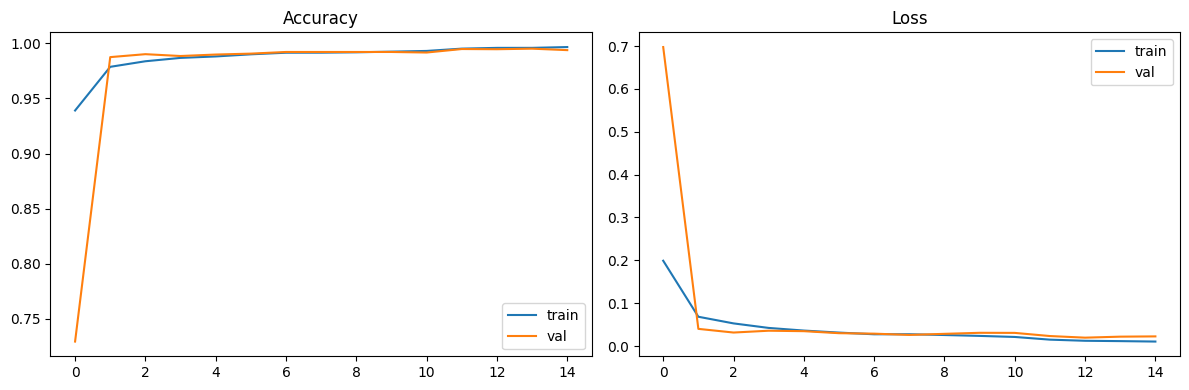

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      0.99      1.00       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



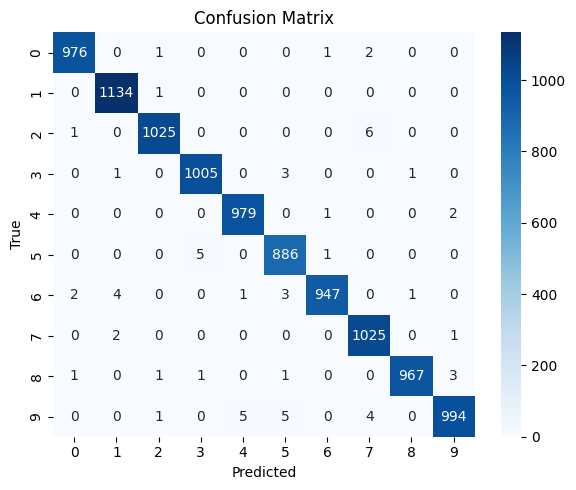

In [5]:
# 5. Evaluate: classification report + confusion matrix + training curves
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy"); axes[0].legend()
axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].legend()
plt.tight_layout(); plt.savefig("models/training_curves.png"); plt.show()

y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.tight_layout(); plt.savefig("models/confusion_matrix.png"); plt.show()

np.save("models/class_names.npy", np.array(class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 571ms/step


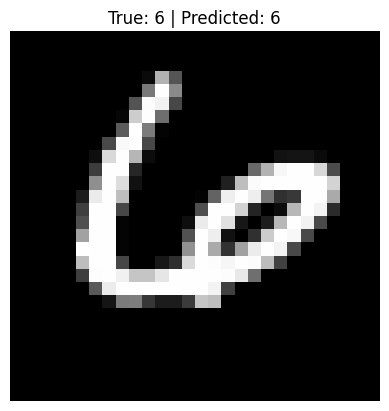

In [6]:
# 6. Predict on a real test digit
idx = np.random.randint(0, len(X_test))
sample = X_test[idx]
true_label = y_test[idx]

probs = model.predict(sample[None, ...])[0]
pred = class_names[np.argmax(probs)]

plt.imshow(sample.squeeze(), cmap="gray")
plt.title(f"True: {true_label} | Predicted: {pred}")
plt.axis("off")
plt.show()

## Optional: also train on EMNIST letters (A-Z)
Run this cell if you want letter recognition too, not just digits.

In [8]:
# 7. Zip up the model + plots to download for your GitHub repo
!zip -r CodeAlpha_HandwrittenCharacterRecognition_results.zip models/
from google.colab import files
files.download('CodeAlpha_HandwrittenCharacterRecognition_results.zip')

  adding: models/ (stored 0%)
  adding: models/class_names.npy (deflated 43%)
  adding: models/confusion_matrix.png (deflated 13%)
  adding: models/char_model.h5 (deflated 12%)
  adding: models/training_curves.png (deflated 11%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>